# Normalizing flows with vectorized micrograd: two moons

A small, tweakable notebook for comparing additive coupling and affine coupling on a toy 2-D dataset using vectorized micrograd.

Run the notebook top-to-bottom to see dataset plots, invertibility checks, NLL curves, generated samples, and a learned log-density grid.


In [1]:
from pathlib import Path
import sys

# Make imports work whether the notebook is in the repo root or in examples/.
CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]

for root in candidates:
    if (root / "vect_micrograd").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError(
        "Could not find the vect_micrograd package. "
        "Open this notebook from the project root or move it into the project."
    )

print("Project root:", PROJECT_ROOT)

Project root: /home/r00t/Downloads/Karpathy/vect_micrograd_flows


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from vect_micrograd.flows import make_flow
from vect_micrograd.optim import Adam, RMSProp

np.set_printoptions(precision=4, suppress=True)

## 1. Tweakable configuration

Start here. The defaults are conservative and should be stable. Increase `steps`, `hidden_sizes`, or `num_coupling_layers` once the basic run looks sane.

In [3]:
# Dataset
n_data = 4096
moon_noise = 0.08
standardize_data = True
seed = 0

# Model
hidden_sizes = (64, 64)
num_coupling_layers = 4
prior = "normal"       # "normal" or "logistic"
flow_kind = "realnvp"  # "nice" for additive coupling, "realnvp" for affine coupling

# Training
steps = 40000
batch_size = 256       # set to n_data for full-batch training
learning_rate = 5e-4
log_every = 200
eval_every = 200

# Stabilizers
use_grad_clip = True
max_grad_norm = 5.0
restore_best_model = True

## 2. Two moons dataset

This implementation avoids scikit-learn so the notebook has fewer dependencies.

In [4]:
def make_two_moons(n, noise=0.08, seed=0, standardize=True, dtype=np.float32):
    rng = np.random.default_rng(seed)
    n1 = n // 2
    n2 = n - n1

    # Upper moon: angle from 0 to pi.
    t1 = rng.uniform(0.0, np.pi, size=n1)
    x1 = np.stack([np.cos(t1), np.sin(t1)], axis=1)

    # Lower moon: shifted and flipped.
    t2 = rng.uniform(0.0, np.pi, size=n2)
    x2 = np.stack([1.0 - np.cos(t2), -np.sin(t2) - 0.5], axis=1)

    X = np.concatenate([x1, x2], axis=0)
    labels = np.concatenate([
        np.zeros(n1, dtype=np.int64),
        np.ones(n2, dtype=np.int64),
    ])

    X = X + noise * rng.standard_normal(X.shape)

    # Shuffle.
    perm = rng.permutation(n)
    X = X[perm]
    labels = labels[perm]

    if standardize:
        X = (X - X.mean(axis=0, keepdims=True)) / X.std(axis=0, keepdims=True)

    return X.astype(dtype, copy=False), labels

X, labels = make_two_moons(
    n_data,
    noise=moon_noise,
    seed=seed,
    standardize=standardize_data,
)

print("X shape:", X.shape)
print("mean:", X.mean(axis=0))
print("std:", X.std(axis=0))

X shape: (4096, 2)
mean: [-0.  0.]
std: [1. 1.]


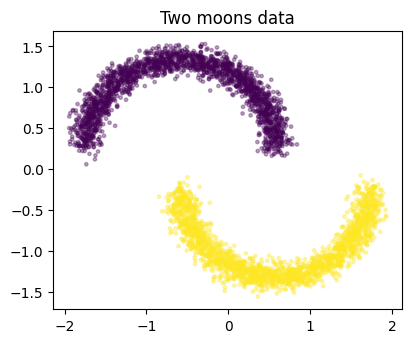

In [5]:
plt.figure(figsize=(4.5, 4.0))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=6, alpha=0.35)
plt.title("Two moons data")
plt.gca().set_aspect("equal")
plt.show()

## 3. Build the flow model

In [6]:
model = make_flow(
    kind=flow_kind,
    dim=2,
    hidden_sizes=hidden_sizes,
    num_coupling_layers=num_coupling_layers,
    prior=prior,
    max_log_scale=2.0,  # used by the Real NVP-style affine builder
)


def init_flow_near_identity(model, output_scale=0.01):
    # Make coupling layers start near identity:
    # additive: y_change = x_change + small t(x_id)
    # affine:   y_change = x_change * exp(small s(x_id)) + small t(x_id)
    for layer in model.flow:
        if hasattr(layer, "net"):
            last = layer.net.layers[-1]
            last.W.data *= output_scale
            if last.b is not None:
                last.b.data.fill(0.0)

    if hasattr(model, "scaling"):
        model.scaling.log_s.data.fill(0.0)


init_flow_near_identity(model)
print(model)


RealNVPFlow(dim=2, layers=4, prior=StandardNormal(dim=2))


## 4. Sanity check: invertibility

In [7]:
z, logdet = model.forward(X[:10])
x_roundtrip = model.inverse(z).data
max_abs_error = np.max(np.abs(x_roundtrip - X[:10]))

print("z shape:", z.data.shape)
print("logdet shape:", logdet.data.shape)
print("logdet:", logdet.data)
print("max |inverse(forward(x)) - x|:", max_abs_error)

z shape: (10, 2)
logdet shape: (10,)
logdet: [-0.0852  0.1195  0.0071  0.0093  0.1032  0.0569 -0.0041 -0.0092  0.1428
 -0.0817]
max |inverse(forward(x)) - x|: 2.3841858e-07


## 5. Training helpers

The loop is intentionally simple: ordinary mini-batch training, optional gradient clipping, full-data NLL evaluation every `eval_every` steps, and best-model restoration.

In [8]:
def save_state(model):
    return [p.data.copy() for p in model.parameters()]


def load_state(model, state):
    for p, saved in zip(model.parameters(), state):
        p.data[...] = saved


def full_nll(model, X, batch_size=2048):
    total = 0.0
    n_total = len(X)

    for start in range(0, n_total, batch_size):
        xb = X[start : start + batch_size]
        n = len(xb)
        total += model.nll(xb).item() * n

    return total / n_total


def clip_grad_norm(parameters, max_norm=5.0):
    total_sq = 0.0

    for p in parameters:
        if p.grad is not None:
            total_sq += float((p.grad.astype(np.float64) ** 2).sum())

    total_norm = total_sq ** 0.5
    scale = min(1.0, max_norm / (total_norm + 1e-12))

    if scale < 1.0:
        for p in parameters:
            if p.grad is not None:
                p.grad *= scale

    return total_norm

## 6. Train

In [9]:
loss_history = []
full_loss_history = []
grad_norm_history = []

params = list(model.parameters())
# optimizer = Adam(params, lr=learning_rate, weight_decay=0.0)
optimizer = RMSProp(params, lr=learning_rate)

best_full_nll = float("inf")
best_state = None
best_step = None

rng = np.random.default_rng(seed + 1)

for step in range(steps):
    if batch_size >= len(X):
        xb = X
    else:
        idx = rng.integers(0, len(X), size=batch_size)
        xb = X[idx]

    optimizer.zero_grad()
    loss = model.nll(xb)
    loss.backward()

    if use_grad_clip:
        grad_norm = clip_grad_norm(params, max_norm=max_grad_norm)
    else:
        grad_norm = np.nan

    optimizer.step(step)

    loss_value = loss.item()
    loss_history.append(loss_value)
    grad_norm_history.append(grad_norm)

    if step % eval_every == 0 or step == steps - 1:
        current_full_nll = full_nll(model, X)
        full_loss_history.append((step, current_full_nll))

        if current_full_nll < best_full_nll:
            best_full_nll = current_full_nll
            best_state = save_state(model)
            best_step = step

        if step % log_every == 0 or step == steps - 1:
            print(
                f"step {step:5d} | "
                f"batch nll {loss_value:.4f} | "
                f"full nll {current_full_nll:.4f} | "
                f"best {best_full_nll:.4f} at step {best_step} | "
                f"grad_norm {grad_norm:.2f}"
            )

if restore_best_model and best_state is not None:
    load_state(model, best_state)
    print(f"restored best model from step {best_step}, full nll={best_full_nll:.4f}")

step     0 | batch nll 2.8451 | full nll 3.1768 | best 3.1768 at step 0 | grad_norm 8.14
step   200 | batch nll 1.7885 | full nll 1.7294 | best 1.7294 at step 200 | grad_norm 28.54
step   400 | batch nll 1.5345 | full nll 1.4897 | best 1.4897 at step 400 | grad_norm 20.46
step   600 | batch nll 1.5603 | full nll 1.4347 | best 1.4347 at step 600 | grad_norm 25.64
step   800 | batch nll 1.5662 | full nll 1.4189 | best 1.4189 at step 800 | grad_norm 29.69
step  1000 | batch nll 1.4771 | full nll 1.4229 | best 1.4189 at step 800 | grad_norm 24.62
step  1200 | batch nll 1.3929 | full nll 1.4013 | best 1.4013 at step 1200 | grad_norm 18.38
step  1400 | batch nll 1.3537 | full nll 1.3813 | best 1.3813 at step 1400 | grad_norm 21.58
step  1600 | batch nll 1.2401 | full nll 1.3478 | best 1.3478 at step 1600 | grad_norm 23.18
step  1800 | batch nll 1.3458 | full nll 1.3526 | best 1.3478 at step 1600 | grad_norm 12.62
step  2000 | batch nll 1.2984 | full nll 1.3818 | best 1.3478 at step 1600 | gr

## 7. Plot training curves

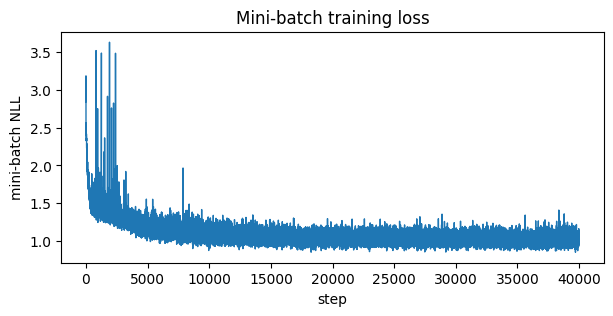

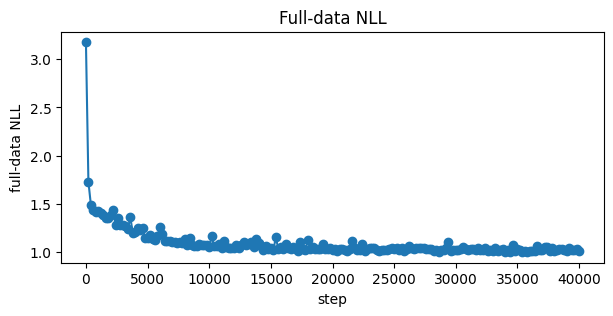

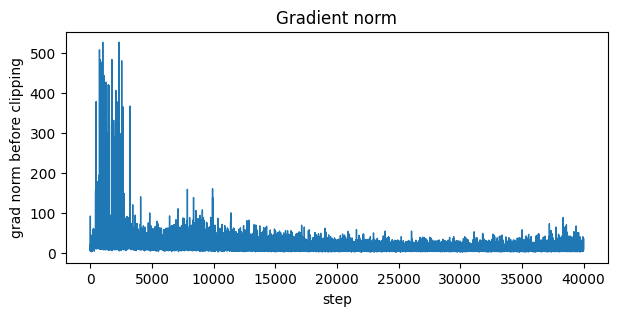

In [10]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history, linewidth=1)
plt.xlabel("step")
plt.ylabel("mini-batch NLL")
plt.title("Mini-batch training loss")
plt.show()

if full_loss_history:
    steps_eval, full_vals = zip(*full_loss_history)
    plt.figure(figsize=(7, 3))
    plt.plot(steps_eval, full_vals, marker="o")
    plt.xlabel("step")
    plt.ylabel("full-data NLL")
    plt.title("Full-data NLL")
    plt.show()

if use_grad_clip:
    plt.figure(figsize=(7, 3))
    plt.plot(grad_norm_history, linewidth=1)
    plt.xlabel("step")
    plt.ylabel("grad norm before clipping")
    plt.title("Gradient norm")
    plt.show()

## 8. Samples

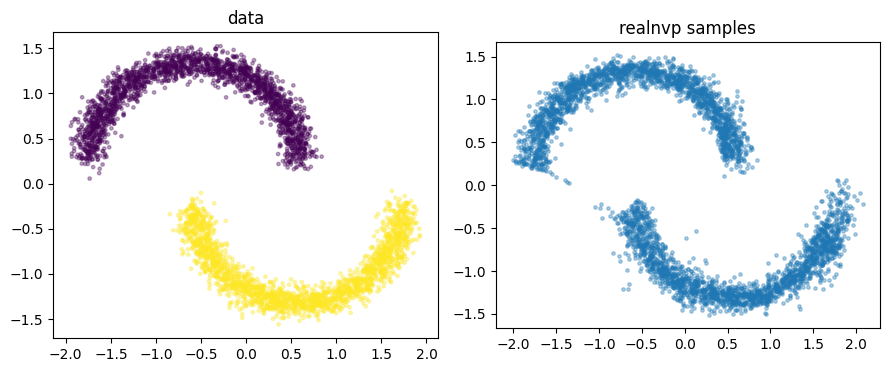

In [11]:
samples = model.sample(len(X))

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=6, alpha=0.35)
plt.title("data")
plt.gca().set_aspect("equal")

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.35)
plt.title(f"{flow_kind} samples")
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.show()

## 9. Learned log-density

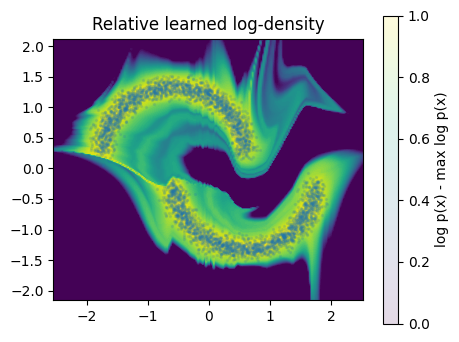

In [12]:
grid_size = 200

x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

xs = np.linspace(x_min, x_max, grid_size)
ys = np.linspace(y_min, y_max, grid_size)

xx, yy = np.meshgrid(xs, ys)
grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(X.dtype)

logp = model.log_prob(grid).data.reshape(grid_size, grid_size)

logp_rel = logp - np.max(logp)
logp_rel_clipped = np.clip(logp_rel, -20.0, 0.0)

plt.figure(figsize=(5, 4))
plt.contourf(
    xx,
    yy,
    logp_rel_clipped,
    levels=np.linspace(-20, 0, 81),
)
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.15)
plt.title("Relative learned log-density")
plt.gca().set_aspect("equal")
plt.colorbar(label="log p(x) - max log p(x)")
plt.show()